In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [ ]:
df = pd.read_excel("/base_evasao.xlsx")
print(df.head())

print()

print(df.info())

print()

print(df.describe())

         MATRICULA  CODIGO_ALUNO               NOME_ALUNO  \
0         71202368        766488     BRUNO FARIAS NASENTE   
1         71801504       1581272  MATHEUS KLUG BITENCOURT   
2         71901127       1674333       JULIA MACHADO FICK   
3  1100002ZB               33946      DARI JUNKER MACHADO   
4        140901589        514638      JULIA QUEVEDO GRAVE   

                                               CURSO       TURMA      TURNO  \
0  CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...  ADS1N20/1   NOITE - N   
1  CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...  ADS1N25/2   NOITE - N   
2  CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...  ADS6N25/2   NOITE - N   
3  CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...  ADS2M25/2   MANHÃ - M   
4  CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...  ADS3N23/2   NOITE - N   

   MODALIDADE           DATA_MATRICULA               DATA_SAIDA  \
0  PRESENCIAL  2020-01-14 00:00:00.000  2020-04-18 00:00:00.000   
1  PRESENCIAL  2025-08-1

In [ ]:
print(df.isnull().sum())
df = df.drop(columns=[
    'MATRICULA',
    'CODIGO_ALUNO',
    'NOME_ALUNO',
    'CURSO',
    'HISTORICO_SITUACAO_ALUNO'
])

MATRICULA                     0
CODIGO_ALUNO                  0
NOME_ALUNO                    0
CURSO                         0
TURMA                         0
TURNO                         0
MODALIDADE                    0
DATA_MATRICULA               69
DATA_SAIDA                  352
HISTORICO_SITUACAO_ALUNO      0
EVASAO                        0
TotalAulas                    0
TotalFaltas                   0
TotalFaltasJustificadas       0
PercentualFaltas            169
SaldoDevedor                  0
ParcelasPendentes             0
PossuiDivida                  0
dtype: int64


In [ ]:
df["DATA_MATRICULA"] = pd.to_datetime(df["DATA_MATRICULA"])
df["DATA_SAIDA"] = pd.to_datetime(df["DATA_SAIDA"])

df["TEMPO_CURSO_DIAS"] = (
    df["DATA_SAIDA"].fillna(pd.Timestamp.today())
    - df["DATA_MATRICULA"]
).dt.days

df.drop(columns=["DATA_MATRICULA","DATA_SAIDA"], inplace=True)

In [ ]:
encoder = LabelEncoder()

for coluna in ["TURMA","TURNO","MODALIDADE"]:
    df[coluna] = encoder.fit_transform(df[coluna].astype(str))


df.fillna(0, inplace=True)

In [ ]:
X = df.drop(columns=["EVASAO"])

y = df["EVASAO"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

In [ ]:
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train,y_train)

pred = modelo.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Accuracy:",accuracy_score(y_test,pred))

print("Precision:",precision_score(y_test,pred))

print("Recall:",recall_score(y_test,pred))

print("F1:",f1_score(y_test,pred))

Accuracy: 0.8852459016393442
Precision: 0.9153846153846154
Recall: 0.9224806201550387
F1: 0.918918918918919


In [ ]:
tree = DecisionTreeClassifier(

    random_state=42,

    max_depth=5

)

tree.fit(X_train,y_train)

pred_tree = tree.predict(X_test)

print(classification_report(y_test,pred_tree))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       108
           1       0.95      0.92      0.94       258

    accuracy                           0.91       366
   macro avg       0.89      0.90      0.89       366
weighted avg       0.91      0.91      0.91       366



In [ ]:
forest = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

forest.fit(X_train,y_train)

pred_rf = forest.predict(X_test)

print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       108
           1       0.96      0.96      0.96       258

    accuracy                           0.95       366
   macro avg       0.93      0.94      0.93       366
weighted avg       0.95      0.95      0.95       366



In [ ]:
importancias = pd.DataFrame({

    "Variavel":X.columns,

    "Importancia":forest.feature_importances_

})

importancias = importancias.sort_values(

    "Importancia",

    ascending=False

)

print(importancias)

                   Variavel  Importancia
10         TEMPO_CURSO_DIAS     0.374315
0                     TURMA     0.243730
3                TotalAulas     0.114498
6          PercentualFaltas     0.076947
8         ParcelasPendentes     0.070733
4               TotalFaltas     0.056040
7              SaldoDevedor     0.038661
9              PossuiDivida     0.011394
1                     TURNO     0.008049
5   TotalFaltasJustificadas     0.005633
2                MODALIDADE     0.000000


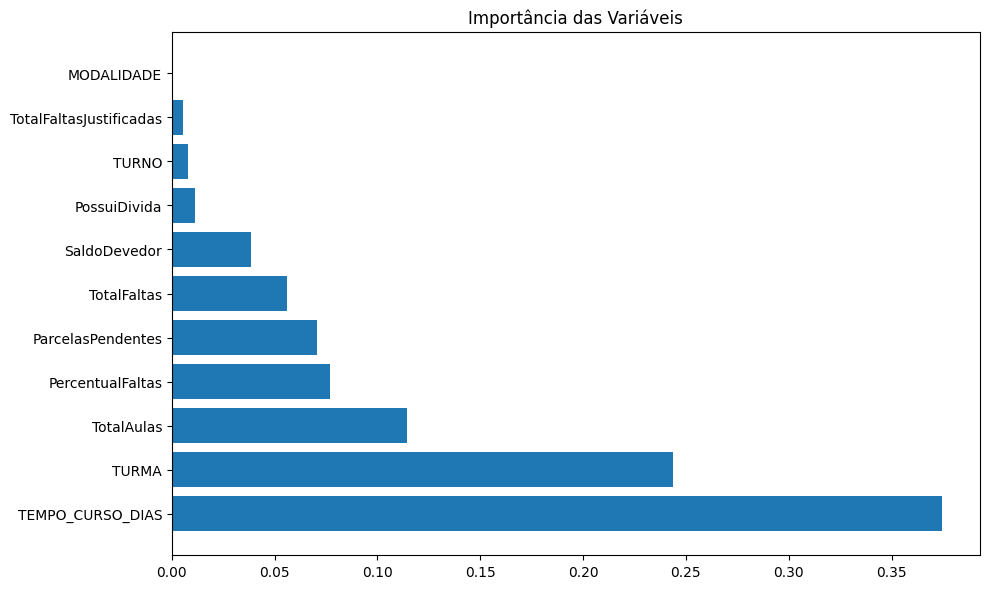

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(

    importancias["Variavel"],

    importancias["Importancia"]

)

plt.title("Importância das Variáveis")

plt.tight_layout()

plt.show()

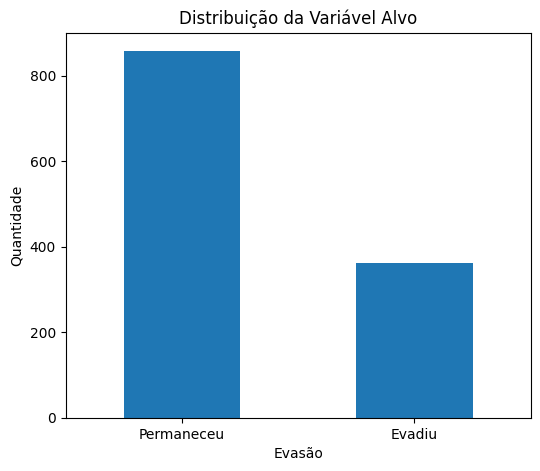

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

df["EVASAO"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuição da Variável Alvo")

plt.xlabel("Evasão")

plt.ylabel("Quantidade")

plt.xticks([0,1],["Permaneceu","Evadiu"],rotation=0)

plt.show()

In [ ]:
evasao = df["EVASAO"].value_counts(normalize=True)*100

print(evasao)

EVASAO
1    70.385562
0    29.614438
Name: proportion, dtype: float64


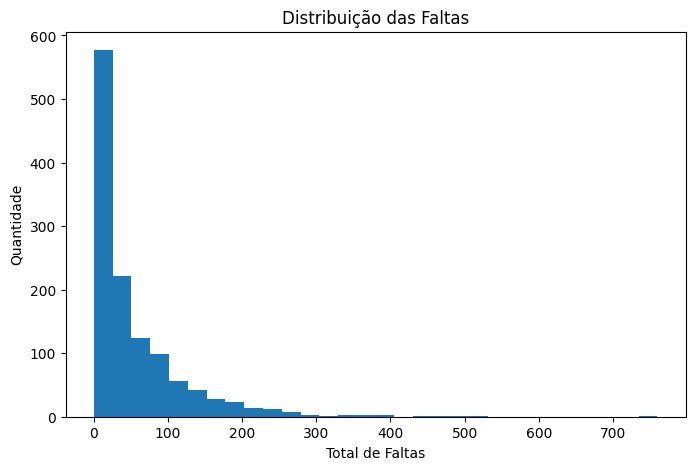

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalFaltas"],bins=30)

plt.title("Distribuição das Faltas")

plt.xlabel("Total de Faltas")

plt.ylabel("Quantidade")

plt.show()

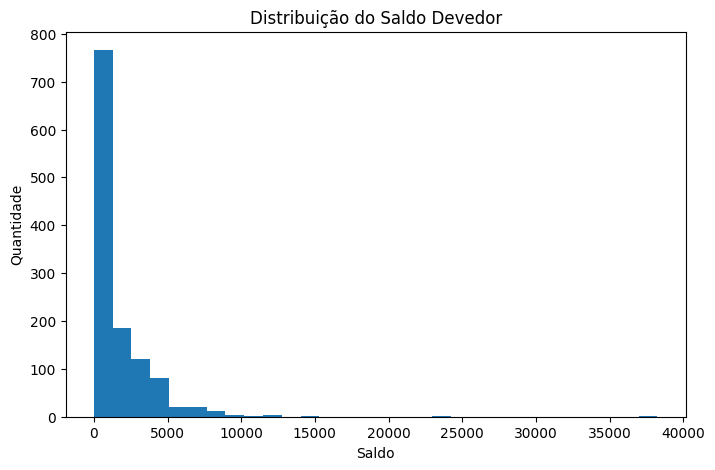

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["SaldoDevedor"],bins=30)

plt.title("Distribuição do Saldo Devedor")

plt.xlabel("Saldo")

plt.ylabel("Quantidade")

plt.show()

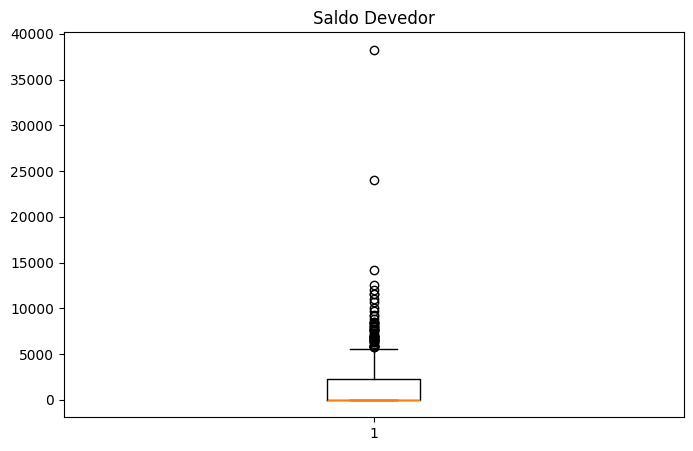

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df["SaldoDevedor"])

plt.title("Saldo Devedor")

plt.show()

<Figure size 800x500 with 0 Axes>

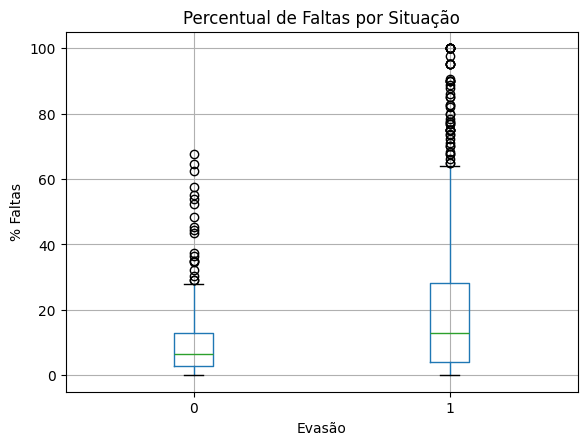

In [ ]:
plt.figure(figsize=(8,5))

df.boxplot(

    column="PercentualFaltas",

    by="EVASAO"

)

plt.title("Percentual de Faltas por Situação")

plt.suptitle("")

plt.xlabel("Evasão")

plt.ylabel("% Faltas")

plt.show()

<Figure size 800x500 with 0 Axes>

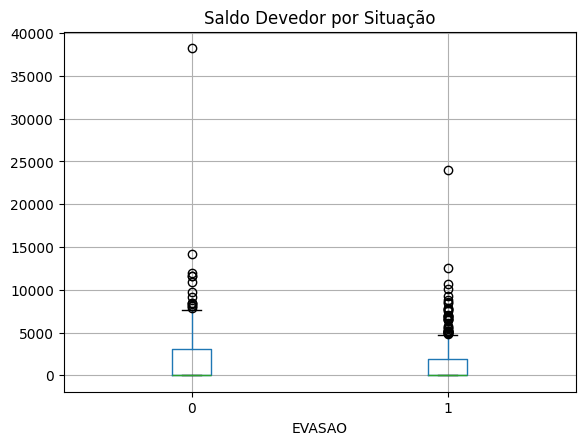

In [ ]:
plt.figure(figsize=(8,5))

df.boxplot(

    column="SaldoDevedor",

    by="EVASAO"

)

plt.title("Saldo Devedor por Situação")

plt.suptitle("")

plt.show()

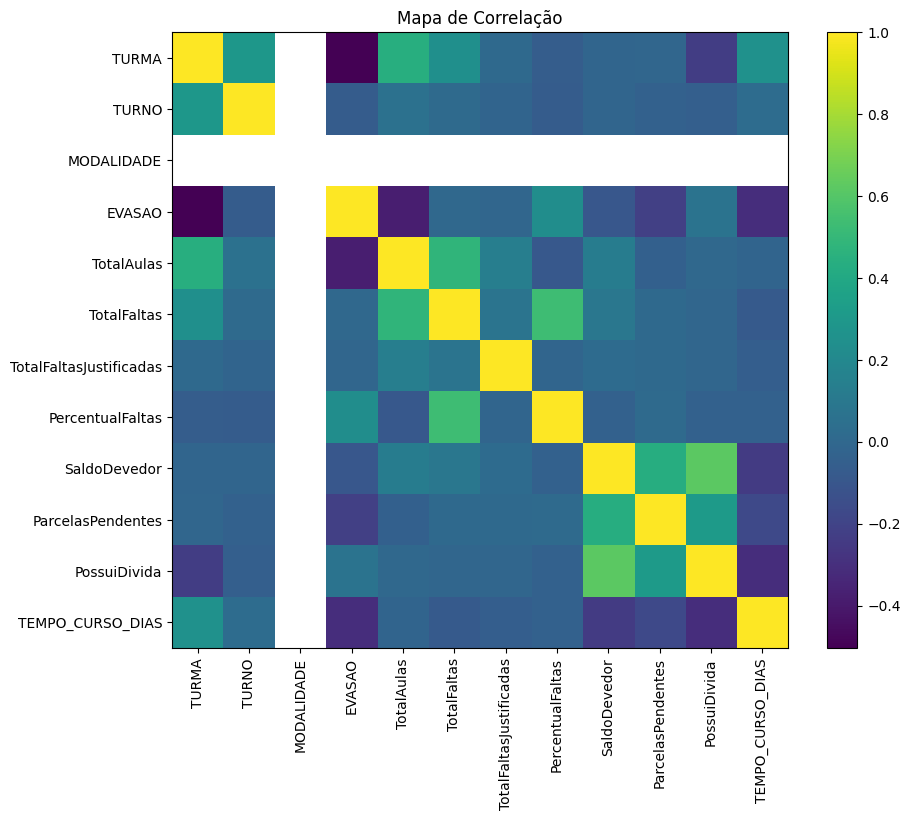

In [ ]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

plt.imshow(corr)

plt.colorbar()

plt.xticks(

    range(len(corr.columns)),

    corr.columns,

    rotation=90

)

plt.yticks(

    range(len(corr.columns)),

    corr.columns

)

plt.title("Mapa de Correlação")

plt.show()

In [ ]:
medias = df.groupby("EVASAO")[
[
    "TotalFaltas",
    "PercentualFaltas",
    "SaldoDevedor",
    "ParcelasPendentes"
]
].mean()

print(medias)

        TotalFaltas  PercentualFaltas  SaldoDevedor  ParcelasPendentes
EVASAO                                                                
0         52.637119          9.696399   1750.341191           0.977839
1         52.861305         19.971981   1257.882786           0.241259


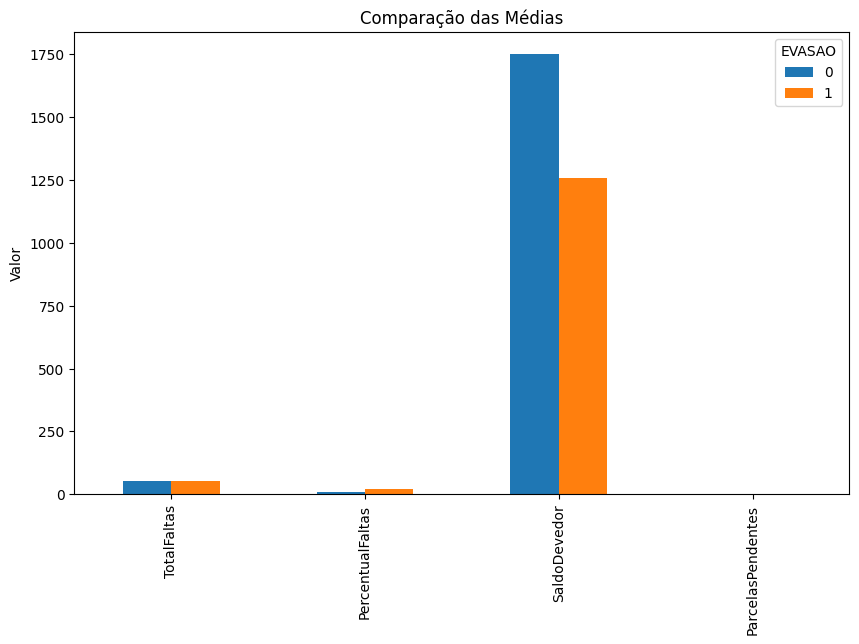

In [ ]:
medias.T.plot(

    kind="bar",

    figsize=(10,6)

)

plt.title("Comparação das Médias")

plt.ylabel("Valor")

plt.show()

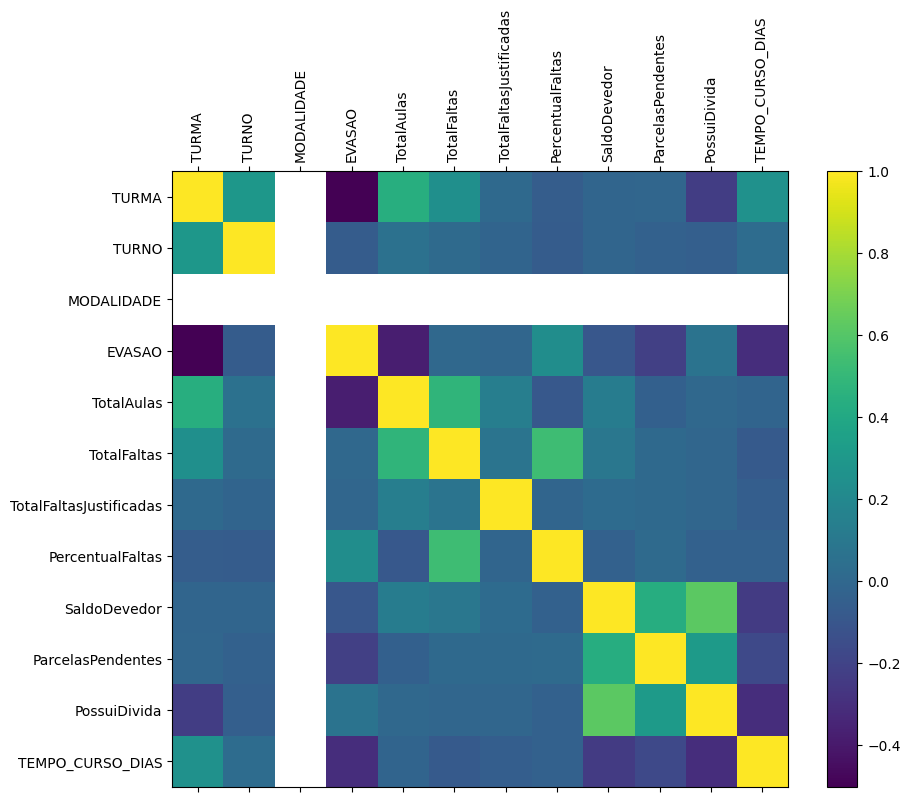

In [ ]:
import numpy as np

corr = df.corr(numeric_only=True)

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111)

cax = ax.matshow(corr)

fig.colorbar(cax)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns,rotation=90)
ax.set_yticklabels(corr.columns)

plt.show()

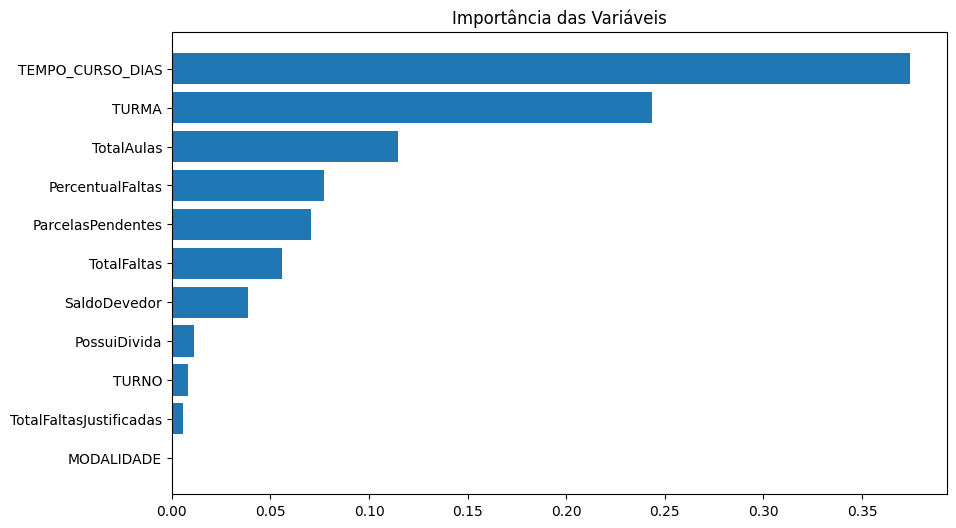

In [ ]:
importancias = pd.DataFrame({

    "Variavel":X.columns,

    "Importancia":forest.feature_importances_

})

importancias = importancias.sort_values(

    "Importancia",

    ascending=False

)

plt.figure(figsize=(10,6))

plt.barh(

    importancias["Variavel"],

    importancias["Importancia"]

)

plt.title("Importância das Variáveis")

plt.gca().invert_yaxis()

plt.show()